In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [ ]:
a=pd.read_csv('/content/synthetic_marketing_data_fixed.csv')

In [ ]:
a.head()

,Client,Industry,Platform,Content_Type,Topic,Posting_Day,Posting_Time,Reach,Likes,Comments,Shares,Saves,Clicks,Leads,Ad_Spend,Revenue,Performance_Score
0,Client_001,Beauty,Instagram,Reel,Customer Story,Tuesday,11,11965,1087,79,66,93,68,3,4639,2815,16.94
1,Client_002,Fitness,Instagram,Static,Tips & Tricks,Thursday,11,15775,1622,33,251,189,213,10,3257,4299,28.77
2,Client_003,Education,Instagram,Carousel,Customer Story,Friday,12,6423,502,39,49,50,165,17,3462,15872,10.40
3,Client_004,Beauty,Instagram,Reel,Behind the Scenes,Sunday,12,9517,1027,43,111,135,86,6,2687,6392,17.69
4,Client_005,Fitness,YouTube Shorts,Reel,Tips & Tricks,Saturday,11,23041,1251,94,174,80,301,36,958,17686,27.54


In [ ]:
#Input features (X)
features = [  'Industry','Platform','Content_Type','Topic',
    'Posting_Day','Posting_Time','Ad_Spend']

In [ ]:
target = 'Performance_Score'
x = a[features]
y = a[target]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2,
                                                    random_state=42 )

In [ ]:
categorical_features = [ 'Industry', 'Platform', 'Content_Type',
                        'Topic', 'Posting_Day' ]

In [ ]:
numeric_features = [ 'Posting_Time', 'Ad_Spend' ]

In [ ]:
categorical_transformer = Pipeline(steps=[ ('imputer',
SimpleImputer(strategy='most_frequent')), ('encoder',
OneHotEncoder(handle_unknown='ignore')) ])
numeric_transformer = Pipeline(steps=[ ('imputer',
SimpleImputer(strategy='median')) ])
preprocessor = ColumnTransformer( transformers=[ ('cat',
categorical_transformer, categorical_features), ('num',
numeric_transformer, numeric_features) ] )

In [ ]:
lr_model = Pipeline(steps=[ ('preprocessor', preprocessor),
 ('model', LinearRegression()) ])

In [ ]:
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)

In [ ]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print('Linear Regression')
print('MAE :', round(lr_mae, 2))
print('RMSE:', round(lr_rmse, 2))
print('R2 :', round(lr_r2, 3))

Linear Regression
MAE : 10.34
RMSE: 13.53
R2 : 0.247


In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

In [ ]:
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print('Random Forest')
print('MAE :', round(rf_mae, 2))
print('RMSE:', round(rf_rmse, 2))
print('R2 :', round(rf_r2, 3))

Random Forest
MAE : 10.22
RMSE: 13.3
R2 : 0.273


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2] })

In [ ]:
comparison.round(3)

,Model,MAE,RMSE,R2
0,Linear Regression,10.336,13.528,0.247
1,Random Forest,10.218,13.295,0.273


In [ ]:
import joblib
joblib.dump(rf_model, 'performance_model.pkl')

['performance_model.pkl']

In [ ]:
results = x_test.copy()
results['Actual_Score'] = y_test.values
results['Predicted_Score'] = rf_pred
results.head()

,Industry,Platform,Content_Type,Topic,Posting_Day,Posting_Time,Ad_Spend,Actual_Score,Predicted_Score
521,Technology,Instagram,Static,Promotion,Saturday,19,4221,19.92,18.402428
737,Fitness,Facebook,Carousel,Product Education,Tuesday,9,3761,8.59,12.299613
740,Fitness,YouTube Shorts,Carousel,Behind the Scenes,Friday,16,903,13.18,20.758835
660,Education,YouTube Shorts,Carousel,Behind the Scenes,Wednesday,10,4496,35.52,24.659807
411,Food,Facebook,Carousel,Promotion,Tuesday,17,2448,18.06,12.021618


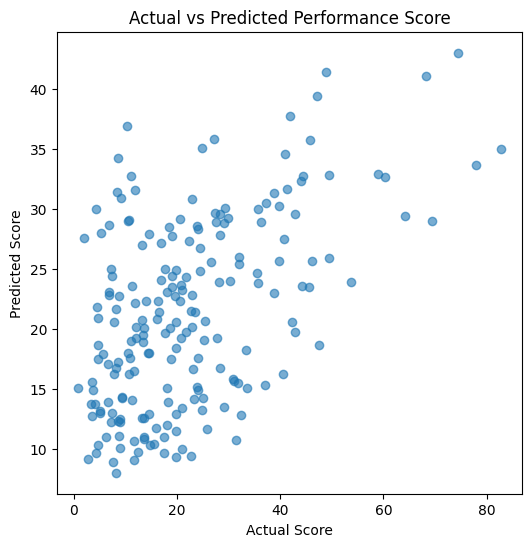

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Performance Score')
plt.show()

In [ ]:
feature_names = x.columns

In [ ]:
feature_names

Index(['Industry', 'Platform', 'Content_Type', 'Topic', 'Posting_Day',
       'Posting_Time', 'Ad_Spend'],
      dtype='object')

In [ ]:
importance = rf_model.named_steps['model'].feature_importances_
importance

array([0.01940959, 0.02029027, 0.02121255, 0.01436254, 0.01359567,
       0.02326538, 0.1304579 , 0.01061404, 0.01056686, 0.01315507,
       0.09236867, 0.04857592, 0.0121337 , 0.01838085, 0.01592375,
       0.02220677, 0.01952083, 0.0187833 , 0.01308963, 0.02017321,
       0.0152828 , 0.01955179, 0.02245713, 0.01537602, 0.12695252,
       0.24229326])

In [ ]:
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

In [ ]:
importance_df = pd.DataFrame({ 'Feature': feature_names, 'Importance':
     importance }).sort_values(by='Importance', ascending=False)

In [ ]:
importance_df.head(10)

,Feature,Importance
25,num__Ad_Spend,0.242293
6,cat__Platform_Facebook,0.130458
24,num__Posting_Time,0.126953
10,cat__Content_Type_Reel,0.092369
11,cat__Content_Type_Static,0.048576
5,cat__Industry_Technology,0.023265
22,cat__Posting_Day_Tuesday,0.022457
15,cat__Topic_Promotion,0.022207
2,cat__Industry_Fashion,0.021213
1,cat__Industry_Education,0.020290


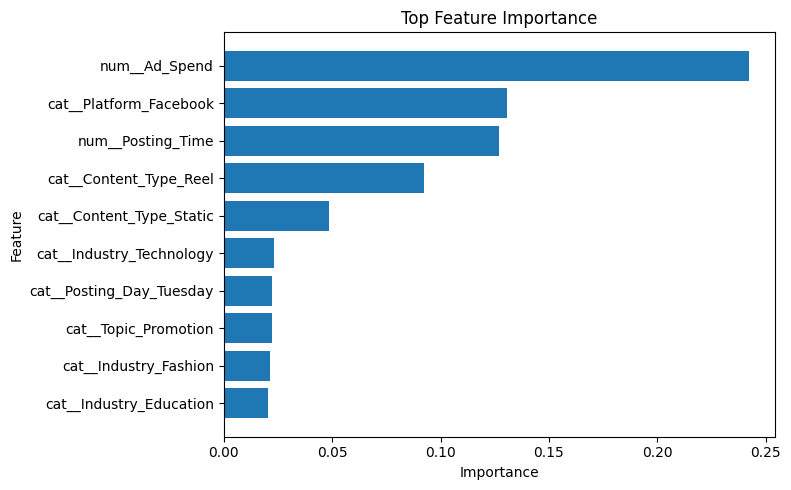

In [ ]:
import matplotlib.pyplot as plt
top_features = importance_df.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

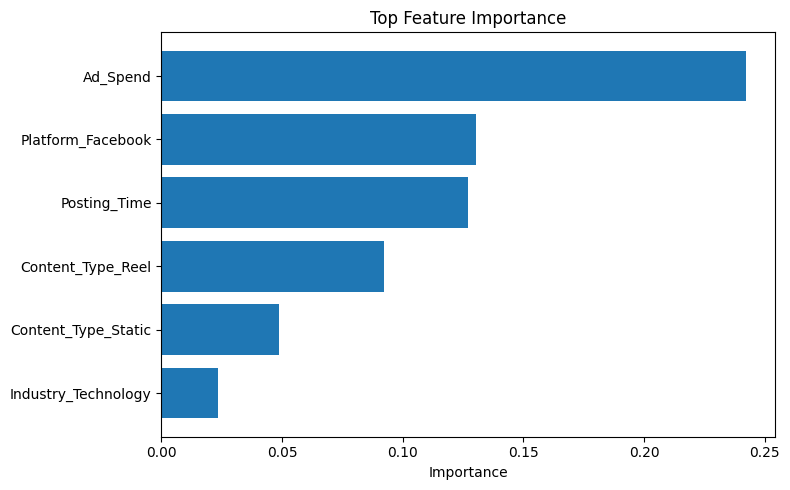

In [ ]:
top6 = importance_df.head(6).copy()
top6['Feature'] = top6['Feature'].str.replace('cat__', '', regex=False)
top6['Feature'] = top6['Feature'].str.replace('num__', '', regex=False)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(top6['Feature'], top6['Importance'])
plt.xlabel('Importance')
plt.title('Top Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()